# Environment Setup & Week 3 Data Pipeline

This notebook prepares the House Prices training data for Week 3 regression work.
It covers preprocessing, feature selection, target transformation, and train-test scaling.

In [1]:
import numpy as np
import pandas as pd

from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# Load data
file_path = "train.csv"
df = pd.read_csv(file_path)

# Standardize column names
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("/", "_", regex=False)
)

# Fill missing values with median for numeric columns and mode for categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

for column in numeric_cols:
    df[column] = df[column].fillna(df[column].median())

for column in categorical_cols:
    mode_value = df[column].mode(dropna=True)
    if not mode_value.empty:
        df[column] = df[column].fillna(mode_value.iloc[0])

# Quality encoding map
quality_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1}
quality_cols = [
    "exterqual",
    "extercond",
    "bsmtqual",
    "bsmtcond",
    "heatingqc",
    "kitchenqual",
    "fireplacequ",
    "garagequal",
    "garagecond",
    "poolqc",
]

for column in quality_cols:
    if column in df.columns:
        mapped_quality = df[column].map(quality_map)
        df[column] = mapped_quality.fillna(mapped_quality.median())

# Frequency encode Neighborhood
if "neighborhood" in df.columns:
    neighborhood_freq = df["neighborhood"].value_counts(normalize=True)
    df["neighborhood"] = df["neighborhood"].map(neighborhood_freq).astype(float)

# One-hot encode remaining nominal columns
nominal_cols = df.select_dtypes(include=["object"]).columns.tolist()
df = pd.get_dummies(df, columns=nominal_cols, drop_first=False)

print("Final preprocessed shape:", df.shape)
print("Total missing values after preprocessing:", df.isnull().sum().sum())

Final preprocessed shape: (1460, 231)
Total missing values after preprocessing: 0


### Step 1 - Load and Preprocess the House Prices Data

This block loads the training data, standardizes the column names, fills missing values, applies quality encoding, frequency-encodes Neighborhood, and one-hot encodes the remaining categorical columns. The goal is to turn the raw table into a clean numeric dataset with no missing values.

In [2]:
# Select top correlated features and prepare the target
saleprice_raw = df["saleprice"].copy()
target_skew_before = saleprice_raw.skew()
y = np.log1p(saleprice_raw)
target_skew_after = y.skew()

correlation_series = df.corr(numeric_only=True)["saleprice"].drop(labels=["saleprice", "pricepersf"], errors="ignore")
top_features = correlation_series.abs().sort_values(ascending=False).head(20).index.tolist()

X = df[top_features].copy()

print("Selected top 20 features:")
print(top_features)
print(f"Target skewness before log1p: {target_skew_before:.4f}")
print(f"Target skewness after log1p: {target_skew_after:.4f}")
print("X shape:", X.shape)
print("y shape:", y.shape)

Selected top 20 features:
['overallqual', 'grlivarea', 'exterqual', 'kitchenqual', 'bsmtqual', 'garagecars', 'garagearea', 'totalbsmtsf', '1stflrsf', 'fullbath', 'totrmsabvgrd', 'yearbuilt', 'garagefinish_Unf', 'yearremodadd', 'foundation_PConc', 'masvnrarea', 'fireplaces', 'garageyrblt', 'bsmtfintype1_GLQ', 'heatingqc']
Target skewness before log1p: 1.8829
Target skewness after log1p: 0.1213
X shape: (1460, 20)
y shape: (1460,)


### Step 2 - Select the Strongest Features and Log-Transform the Target

This block keeps the 20 features most correlated with SalePrice, removes SalePrice and PricePerSF from the candidate list, and applies np.log1p() to the target. The log transform reduces right skew and makes the regression target easier to model.

In [3]:
# Train-test split and standardize features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled mean: {X_train_scaled.mean():.6f}")
print(f"X_train_scaled std: {X_train_scaled.std():.6f}")
print(f"X_test_scaled mean: {X_test_scaled.mean():.6f}")
print(f"X_test_scaled std: {X_test_scaled.std():.6f}")

X_train shape: (1168, 20)
X_test shape: (292, 20)
y_train shape: (1168,)
y_test shape: (292,)
X_train_scaled mean: 0.000000
X_train_scaled std: 1.000000
X_test_scaled mean: -0.027651
X_test_scaled std: 1.017381


The test set is transformed using the same scaling parameters learned from the training set. Because the scaler is fit only on `X_train`, `X_test_scaled` is not expected to have exact mean 0 and standard deviation 1. It reflects how unseen data shifts relative to the training distribution.

## Step 5 - Baseline Linear Regression

This section fits a baseline linear regression model, evaluates it on the training and test sets, and inspects the strongest coefficients.

## Step 6 - Polynomial Regression Degree Comparison

This section compares polynomial feature expansions of degrees 1, 2, and 3 using the same train/test split.

In [14]:
from typing import Any, Dict, Sequence

import matplotlib.pyplot as plt
import seaborn as sns


def evaluate_model(y_true: Sequence[float], y_pred: Sequence[float], model_name: str, n_features: int) -> Dict[str, float]:
    """Evaluate regression predictions with standard error metrics.

    Parameters
    ----------
    y_true : Sequence[float]
        Ground-truth target values.
    y_pred : Sequence[float]
        Model predictions aligned with ``y_true``.
    model_name : str
        Name of the model being evaluated.
    n_features : int
        Number of input features used by the model, for adjusted R-squared.

    Returns
    -------
    Dict[str, float]
        Dictionary containing MAE, MSE, RMSE, R2, adjusted R2, and MAPE.
    """
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)
    n_samples = y_true_array.shape[0]

    mae = mean_absolute_error(y_true_array, y_pred_array)
    mse = mean_squared_error(y_true_array, y_pred_array)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_array, y_pred_array)

    denominator = n_samples - n_features - 1
    adjusted_r2 = 1.0 - ((1.0 - r2) * (n_samples - 1) / denominator) if denominator > 0 else np.nan
    mape = np.mean(np.abs((y_true_array - y_pred_array) / np.where(np.abs(y_true_array) < 1e-8, np.nan, y_true_array))) * 100

    results = {
        "model_name": model_name,
        "mae": float(mae),
        "mse": float(mse),
        "rmse": float(rmse),
        "r2": float(r2),
        "adjusted_r2": float(adjusted_r2),
        "mape": float(mape),
    }

    print(f"\n{model_name} Evaluation")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"Adjusted R²: {adjusted_r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return results


def plot_actual_vs_predicted(y_true: Sequence[float], y_pred: Sequence[float], model_name: str) -> None:
    """Plot actual values against predictions with a reference line.

    Parameters
    ----------
    y_true : Sequence[float]
        Ground-truth target values.
    y_pred : Sequence[float]
        Model predictions aligned with ``y_true``.
    model_name : str
        Name of the model to show in the plot title.

    Returns
    -------
    None
        Displays a scatter plot with a perfect-prediction diagonal and metric annotations.
    """
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)
    r2 = r2_score(y_true_array, y_pred_array)
    rmse = np.sqrt(mean_squared_error(y_true_array, y_pred_array))

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true_array, y=y_pred_array, alpha=0.7, edgecolor=None)
    min_value = min(y_true_array.min(), y_pred_array.min())
    max_value = max(y_true_array.max(), y_pred_array.max())
    plt.plot([min_value, max_value], [min_value, max_value], linestyle="--", color="black", linewidth=2)
    plt.title(f"Actual vs Predicted - {model_name}")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.text(0.05, 0.95, f"R² = {r2:.4f}\nRMSE = {rmse:.4f}", transform=plt.gca().transAxes, verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    plt.tight_layout()
    plt.show()

### Step 3 - Split the Data and Scale the Features

This block splits the data into training and test sets, then fits StandardScaler on the training features only. The same scaler is reused on the test set so the evaluation stays realistic and avoids data leakage.


Linear Regression - Train Evaluation
MAE: 0.1087
MSE: 0.0250
RMSE: 0.1581
R²: 0.8360
Adjusted R²: 0.8331
MAPE: 0.9095%

Linear Regression - Test Evaluation
MAE: 0.1185
MSE: 0.0273
RMSE: 0.1652
R²: 0.8537
Adjusted R²: 0.8429
MAPE: 0.9989%


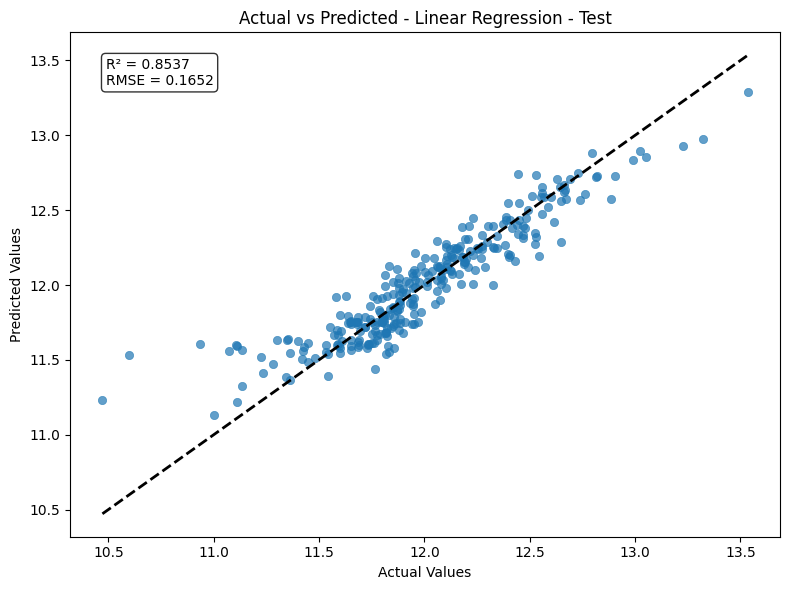

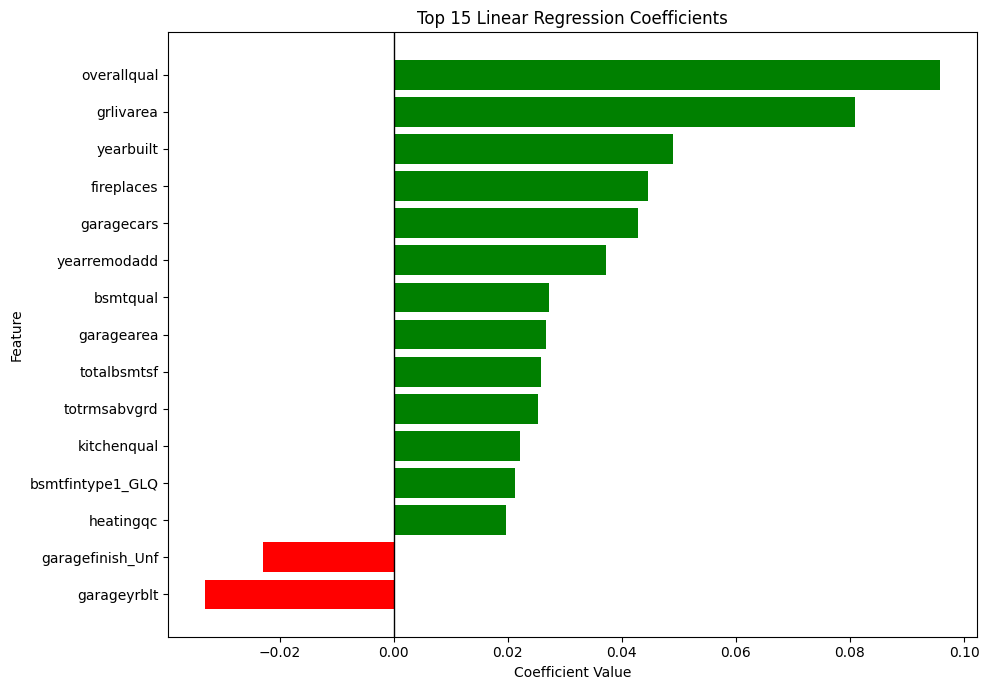

Top 15 influential features by absolute coefficient:
         feature  coefficient
     overallqual     0.095787
       grlivarea     0.080856
       yearbuilt     0.048946
      fireplaces     0.044639
      garagecars     0.042753
    yearremodadd     0.037216
     garageyrblt    -0.033055
        bsmtqual     0.027194
      garagearea     0.026632
     totalbsmtsf     0.025836
    totrmsabvgrd     0.025341
garagefinish_Unf    -0.022941
     kitchenqual     0.022143
bsmtfintype1_GLQ     0.021346
       heatingqc     0.019720
Strongest positive impact feature: overallqual


In [5]:
# Baseline linear regression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_train_pred_linear = linear_model.predict(X_train_scaled)
y_test_pred_linear = linear_model.predict(X_test_scaled)

train_results_linear = evaluate_model(y_train, y_train_pred_linear, "Linear Regression - Train", X_train_scaled.shape[1])
test_results_linear = evaluate_model(y_test, y_test_pred_linear, "Linear Regression - Test", X_train_scaled.shape[1])

plot_actual_vs_predicted(y_test, y_test_pred_linear, "Linear Regression - Test")

# Coefficient importance plot
coefficient_frame = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": linear_model.coef_,
})
coefficient_frame["abs_coefficient"] = coefficient_frame["coefficient"].abs()
top_coefficients = coefficient_frame.sort_values("abs_coefficient", ascending=False).head(15).sort_values("coefficient")
top_positive_feature = coefficient_frame.sort_values("coefficient", ascending=False).iloc[0]["feature"]

bar_colors = ["green" if value > 0 else "red" for value in top_coefficients["coefficient"]]

plt.figure(figsize=(10, 7))
plt.barh(top_coefficients["feature"], top_coefficients["coefficient"], color=bar_colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Top 15 Linear Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top 15 influential features by absolute coefficient:")
print(top_coefficients.sort_values("abs_coefficient", ascending=False)[["feature", "coefficient"]].to_string(index=False))
print(f"Strongest positive impact feature: {top_positive_feature}")

### Step 5 - Train the Baseline Linear Regression Model

This block fits the simplest regression model, evaluates it on both train and test data, and plots the predictions against the actual values. It also shows which coefficients matter most and whether they increase or decrease the predicted price.

The training and test R² are very similar here: train R² = 0.8360 and test R² = 0.8537, so the gap is small and slightly favors the test set. That suggests the baseline model generalizes well rather than overfitting. The feature with the strongest positive impact on predicted price is `overallqual`.

## Part B - Polynomial Regression

The following section compares polynomial feature expansions of degrees 1, 2, and 3 using the same training and test split.

 degree  n_features_after_expansion  train_R2     test_R2        gap
      1                          20  0.835970    0.853672  -0.017702
      2                         230  0.907567    0.836979   0.070588
      3                        1770  0.999919 -630.491652 631.491571


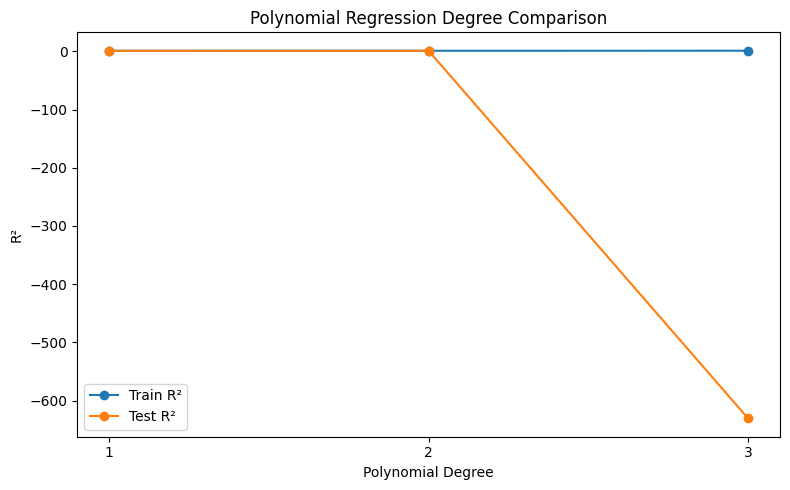

In [6]:
from sklearn.preprocessing import PolynomialFeatures

polynomial_results = []
degree_values = [1, 2, 3]

for degree in degree_values:
    polynomial_pipeline = Pipeline(
        steps=[
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]
    )
    polynomial_pipeline.fit(X_train, y_train)

    y_train_pred_poly = polynomial_pipeline.predict(X_train)
    y_test_pred_poly = polynomial_pipeline.predict(X_test)

    train_r2_poly = r2_score(y_train, y_train_pred_poly)
    test_r2_poly = r2_score(y_test, y_test_pred_poly)
    gap_poly = train_r2_poly - test_r2_poly
    n_features_after_expansion = polynomial_pipeline.named_steps["poly"].n_output_features_

    polynomial_results.append(
        {
            "degree": degree,
            "n_features_after_expansion": n_features_after_expansion,
            "train_R2": train_r2_poly,
            "test_R2": test_r2_poly,
            "gap": gap_poly,
        }
    )

polynomial_comparison = pd.DataFrame(polynomial_results)
print(polynomial_comparison.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(polynomial_comparison["degree"], polynomial_comparison["train_R2"], marker="o", label="Train R²")
plt.plot(polynomial_comparison["degree"], polynomial_comparison["test_R2"], marker="o", label="Test R²")
plt.xticks(degree_values)
plt.xlabel("Polynomial Degree")
plt.ylabel("R²")
plt.title("Polynomial Regression Degree Comparison")
plt.legend()
plt.tight_layout()
plt.show()

Overfitting begins at degree 2. The train R² rises to 0.9076 while the test R² drops to 0.8370, creating a gap of about 0.0706. By degree 3, the feature count jumps to 1770 and the test R² collapses, which is a classic sign that the model has become too complex and is fitting noise instead of general patterns.

## Step 7 - Ridge Regression Alpha Exploration

This section tunes Ridge regression across several alpha values and compares the manual search with GridSearchCV.

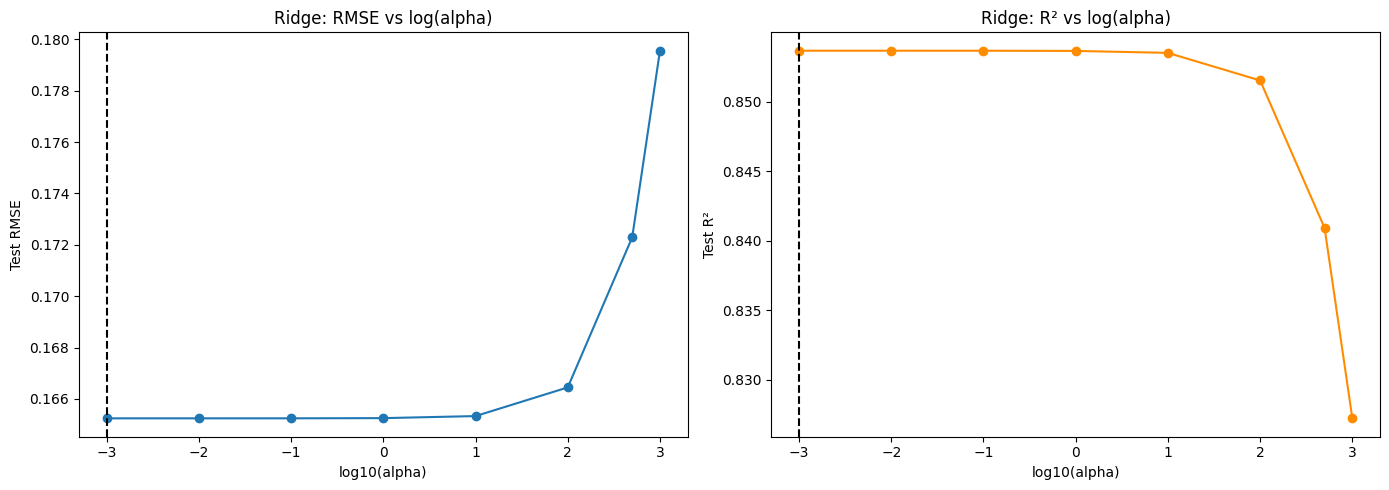

Ridge alpha search results:
   alpha  test_rmse  test_r2
   0.001   0.165247 0.853672
   0.010   0.165247 0.853672
   0.100   0.165247 0.853671
   1.000   0.165255 0.853658
  10.000   0.165334 0.853516
 100.000   0.166451 0.851532
 500.000   0.172294 0.840925
1000.000   0.179558 0.827228
Manual best alpha: 0.001
GridSearch best alpha: 100
Do they match? No
Best Ridge test R² from GridSearch: 0.8515


In [7]:
# Ridge regression alpha exploration
ridge_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]
ridge_results = []

for alpha in ridge_alphas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_scaled, y_train)
    ridge_test_pred = ridge_model.predict(X_test_scaled)
    ridge_results.append(
        {
            "alpha": alpha,
            "test_rmse": np.sqrt(mean_squared_error(y_test, ridge_test_pred)),
            "test_r2": r2_score(y_test, ridge_test_pred),
        }
    )

ridge_results_df = pd.DataFrame(ridge_results)
manual_best_ridge_row = ridge_results_df.loc[ridge_results_df["test_rmse"].idxmin()]
manual_best_ridge_alpha = manual_best_ridge_row["alpha"]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(np.log10(ridge_results_df["alpha"]), ridge_results_df["test_rmse"], marker="o")
plt.axvline(np.log10(manual_best_ridge_alpha), linestyle="--", color="black")
plt.xlabel("log10(alpha)")
plt.ylabel("Test RMSE")
plt.title("Ridge: RMSE vs log(alpha)")

plt.subplot(1, 2, 2)
plt.plot(np.log10(ridge_results_df["alpha"]), ridge_results_df["test_r2"], marker="o", color="darkorange")
plt.axvline(np.log10(manual_best_ridge_alpha), linestyle="--", color="black")
plt.xlabel("log10(alpha)")
plt.ylabel("Test R²")
plt.title("Ridge: R² vs log(alpha)")

plt.tight_layout()
plt.show()

ridge_grid = GridSearchCV(Ridge(), param_grid={"alpha": ridge_alphas}, cv=5, scoring="r2")
ridge_grid.fit(X_train_scaled, y_train)

best_ridge_model = ridge_grid.best_estimator_
best_ridge_alpha = ridge_grid.best_params_["alpha"]
best_ridge_test_pred = best_ridge_model.predict(X_test_scaled)

print("Ridge alpha search results:")
print(ridge_results_df.to_string(index=False))
print(f"Manual best alpha: {manual_best_ridge_alpha}")
print(f"GridSearch best alpha: {best_ridge_alpha}")
print(f"Do they match? {'Yes' if manual_best_ridge_alpha == best_ridge_alpha else 'No'}")
print(f"Best Ridge test R² from GridSearch: {r2_score(y_test, best_ridge_test_pred):.4f}")

### Step 7 - Tune Ridge Regression

This block tests several Ridge alpha values, plots how RMSE and R² change, and then uses cross-validation to choose the best alpha automatically. It is a regularization check that shows how much shrinkage helps the model.

## Step 8 - Lasso Regression Feature Elimination Analysis

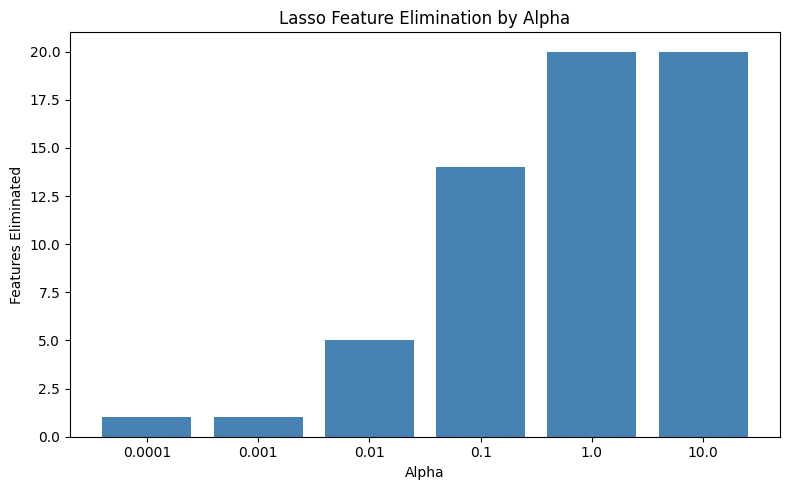

Lasso alpha search results:
  alpha  n_features_eliminated  pct_eliminated  test_rmse   test_r2
 0.0001                      1             5.0   0.165235  0.853693
 0.0010                      1             5.0   0.165220  0.853719
 0.0100                      5            25.0   0.168533  0.847793
 0.1000                     14            70.0   0.239359  0.692983
 1.0000                     20           100.0   0.433244 -0.005837
10.0000                     20           100.0   0.433244 -0.005837
Best alpha from GridSearch: 0.001
Best Lasso test R² from GridSearch: 0.8537
Surviving features:
['overallqual', 'grlivarea', 'kitchenqual', 'bsmtqual', 'garagecars', 'garagearea', 'totalbsmtsf', '1stflrsf', 'fullbath', 'totrmsabvgrd', 'yearbuilt', 'garagefinish_Unf', 'yearremodadd', 'foundation_PConc', 'masvnrarea', 'fireplaces', 'garageyrblt', 'bsmtfintype1_GLQ', 'heatingqc']
Eliminated features:
['exterqual']


In [8]:
# Lasso regression feature elimination analysis
lasso_alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10]
lasso_results = []

for alpha in lasso_alphas:
    lasso_model = Lasso(alpha=alpha, max_iter=20000)
    lasso_model.fit(X_train_scaled, y_train)
    lasso_test_pred = lasso_model.predict(X_test_scaled)
    eliminated = int(np.sum(lasso_model.coef_ == 0))
    lasso_results.append(
        {
            "alpha": alpha,
            "n_features_eliminated": eliminated,
            "pct_eliminated": (eliminated / X_train_scaled.shape[1]) * 100,
            "test_rmse": np.sqrt(mean_squared_error(y_test, lasso_test_pred)),
            "test_r2": r2_score(y_test, lasso_test_pred),
        }
    )

lasso_results_df = pd.DataFrame(lasso_results)

plt.figure(figsize=(8, 5))
plt.bar(lasso_results_df["alpha"].astype(str), lasso_results_df["n_features_eliminated"], color="steelblue")
plt.xlabel("Alpha")
plt.ylabel("Features Eliminated")
plt.title("Lasso Feature Elimination by Alpha")
plt.tight_layout()
plt.show()

lasso_grid = GridSearchCV(Lasso(max_iter=20000), param_grid={"alpha": lasso_alphas}, cv=5, scoring="r2")
lasso_grid.fit(X_train_scaled, y_train)

best_lasso_model = lasso_grid.best_estimator_
best_lasso_alpha = lasso_grid.best_params_["alpha"]
best_lasso_test_pred = best_lasso_model.predict(X_test_scaled)
lasso_surviving_features = X_train.columns[best_lasso_model.coef_ != 0].tolist()
lasso_eliminated_features = X_train.columns[best_lasso_model.coef_ == 0].tolist()

print("Lasso alpha search results:")
print(lasso_results_df.to_string(index=False))
print(f"Best alpha from GridSearch: {best_lasso_alpha}")
print(f"Best Lasso test R² from GridSearch: {r2_score(y_test, best_lasso_test_pred):.4f}")
print("Surviving features:")
print(lasso_surviving_features)
print("Eliminated features:")
print(lasso_eliminated_features)

### Step 8 - Analyze Lasso Feature Elimination

This block checks how Lasso removes weak features by forcing some coefficients to exactly zero. The surviving features are the ones Lasso considers most useful for prediction, while the eliminated features are the least helpful under stronger sparsity pressure.

## Step 9 - ElasticNet l1_ratio Exploration

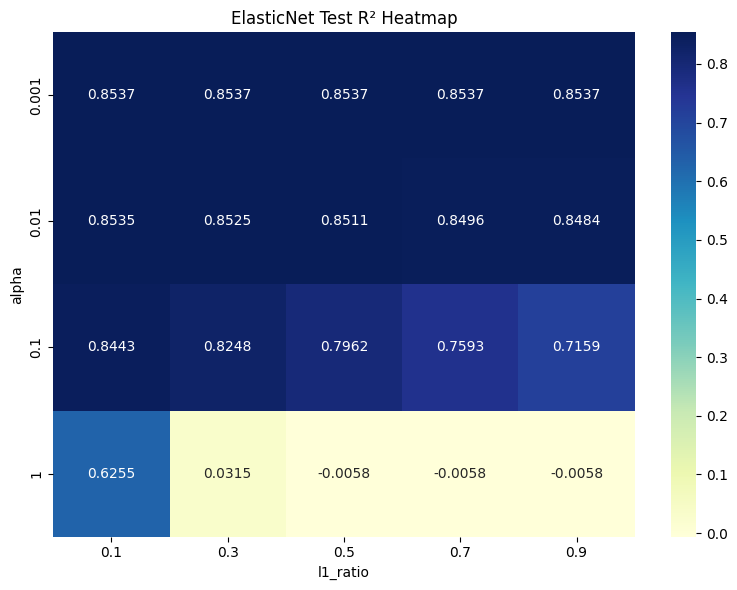

Best ElasticNet parameters:
{'alpha': 0.01, 'l1_ratio': 0.3}
Best ElasticNet test R²: 0.8525
Best Ridge test R²: 0.8515
Best Lasso test R²: 0.8537


In [9]:
# ElasticNet l1_ratio exploration
elasticnet_alphas = [0.001, 0.01, 0.1, 1]
elasticnet_l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
elasticnet_results = []

for alpha in elasticnet_alphas:
    row = {"alpha": alpha}
    for l1_ratio in elasticnet_l1_ratios:
        elastic_model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=20000)
        elastic_model.fit(X_train_scaled, y_train)
        elastic_test_pred = elastic_model.predict(X_test_scaled)
        row[l1_ratio] = r2_score(y_test, elastic_test_pred)
        elasticnet_results.append(
            {
                "alpha": alpha,
                "l1_ratio": l1_ratio,
                "test_r2": row[l1_ratio],
            }
        )
    
    if alpha == elasticnet_alphas[0]:
        elasticnet_heatmap_frame = pd.DataFrame(columns=elasticnet_l1_ratios)
    elasticnet_heatmap_frame.loc[alpha] = [row[l1_ratio] for l1_ratio in elasticnet_l1_ratios]

plt.figure(figsize=(8, 6))
sns.heatmap(elasticnet_heatmap_frame, annot=True, fmt=".4f", cmap="YlGnBu", xticklabels=elasticnet_l1_ratios, yticklabels=elasticnet_alphas)
plt.xlabel("l1_ratio")
plt.ylabel("alpha")
plt.title("ElasticNet Test R² Heatmap")
plt.tight_layout()
plt.show()

elasticnet_grid = GridSearchCV(
    ElasticNet(max_iter=20000),
    param_grid={"alpha": elasticnet_alphas, "l1_ratio": elasticnet_l1_ratios},
    cv=5,
    scoring="r2",
)
elasticnet_grid.fit(X_train_scaled, y_train)

best_elasticnet_model = elasticnet_grid.best_estimator_
best_elasticnet_alpha = elasticnet_grid.best_params_["alpha"]
best_elasticnet_l1_ratio = elasticnet_grid.best_params_["l1_ratio"]
best_elasticnet_test_pred = best_elasticnet_model.predict(X_test_scaled)
best_elasticnet_test_r2 = r2_score(y_test, best_elasticnet_test_pred)

print("Best ElasticNet parameters:")
print(elasticnet_grid.best_params_)
print(f"Best ElasticNet test R²: {best_elasticnet_test_r2:.4f}")
print(f"Best Ridge test R²: {r2_score(y_test, best_ridge_test_pred):.4f}")
print(f"Best Lasso test R²: {r2_score(y_test, best_lasso_test_pred):.4f}")

### Step 9 - Tune ElasticNet

This block explores ElasticNet across alpha and l1_ratio values. It combines Ridge-like shrinkage and Lasso-like sparsity, so the heatmap helps show which balance works best for this dataset.

## Step 10 - Polynomial + Ridge Pipeline


Polynomial + Ridge - Test Evaluation
MAE: 0.1129
MSE: 0.0258
RMSE: 0.1607
R²: 0.8616
Adjusted R²: 0.8514
MAPE: 0.9514%
Best Polynomial + Ridge parameters:
{'poly__degree': 2, 'ridge__alpha': 10}
Best Polynomial + Ridge test R²: 0.8616


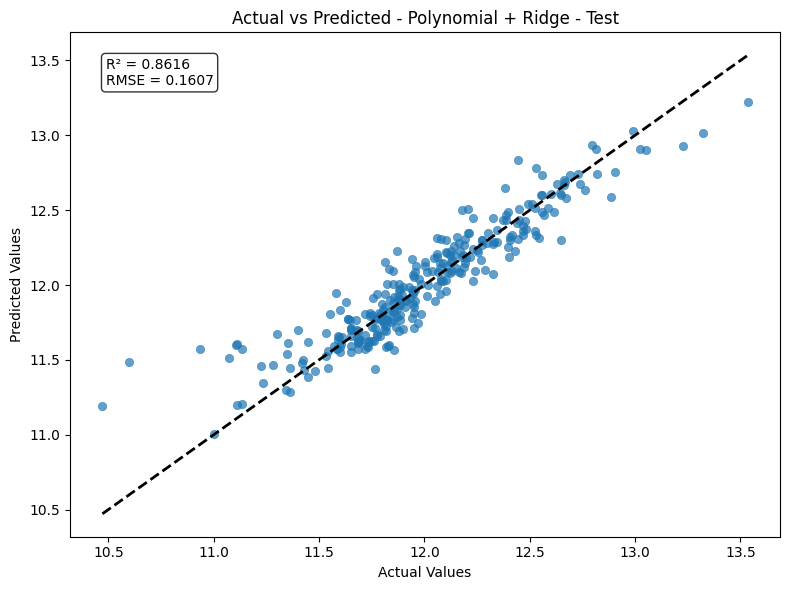

In [10]:
# Polynomial + Ridge pipeline
poly_ridge_pipeline = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(include_bias=False)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge()),
    ]
)

poly_ridge_grid = GridSearchCV(
    poly_ridge_pipeline,
    param_grid={"poly__degree": [1, 2], "ridge__alpha": [0.01, 0.1, 1, 10, 100]},
    cv=5,
    scoring="r2",
)
poly_ridge_grid.fit(X_train, y_train)

best_poly_ridge_model = poly_ridge_grid.best_estimator_
best_poly_ridge_test_pred = best_poly_ridge_model.predict(X_test)
best_poly_ridge_test_results = evaluate_model(y_test, best_poly_ridge_test_pred, "Polynomial + Ridge - Test", X_train.shape[1])

print("Best Polynomial + Ridge parameters:")
print(poly_ridge_grid.best_params_)
print(f"Best Polynomial + Ridge test R²: {best_poly_ridge_test_results['r2']:.4f}")
plot_actual_vs_predicted(y_test, best_poly_ridge_test_pred, "Polynomial + Ridge - Test")

### Step 10 - Polynomial Features with Ridge

This block adds interaction and polynomial terms, then uses Ridge to control the large feature space. It tests whether a small amount of nonlinearity improves predictions without causing the model to overfit badly.

## Step 11 - Final Model Comparison

## Part C - Residual Analysis, Cross-Validation & Diagnostics

This section evaluates the best model with residual diagnostics, 5-fold cross-validation, learning curves, and coefficient-path visualizations.

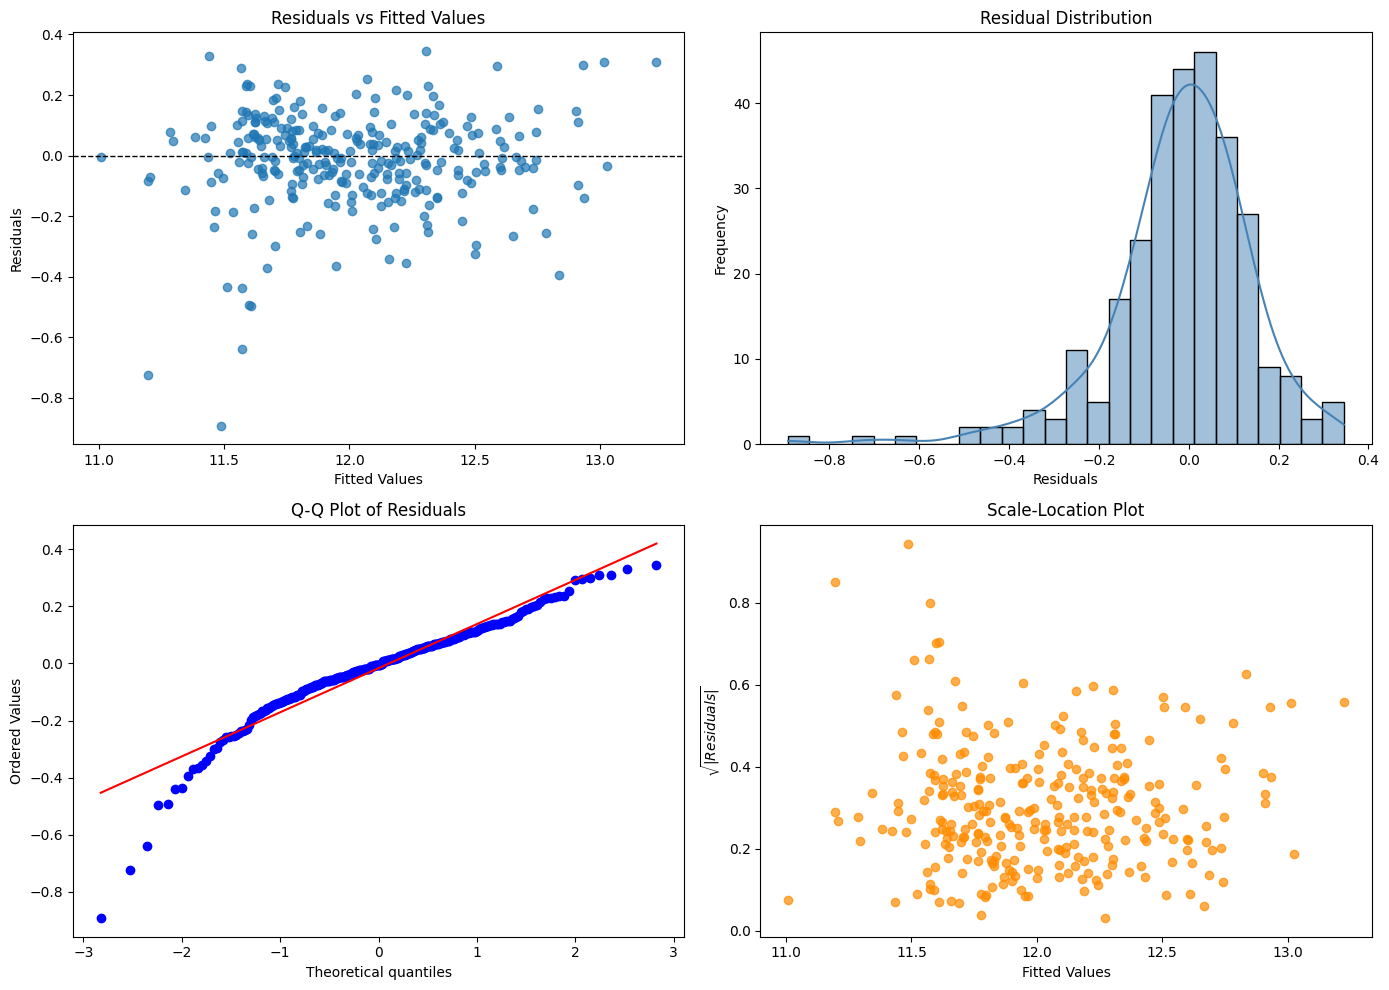

Shapiro-Wilk statistic: 0.9227
Shapiro-Wilk p-value: 0.000000
Residuals do not appear normally distributed.

Linear Regression fold R² scores: [0.8537 0.8707 0.6153 0.8489 0.8716]
Linear Regression fold RMSE scores: [0.1652 0.1417 0.2328 0.1635 0.132 ]
Linear Regression mean R²: 0.8120, std R²: 0.0988
Linear Regression mean RMSE: 0.1670, std RMSE: 0.0352

Best Ridge fold R² scores: [0.8515 0.869  0.649  0.8447 0.8713]
Best Ridge fold RMSE scores: [0.1665 0.1427 0.2223 0.1657 0.1321]
Best Ridge mean R²: 0.8171, std R²: 0.0846
Best Ridge mean RMSE: 0.1659, std RMSE: 0.0312

Best Lasso fold R² scores: [0.8537 0.8708 0.6184 0.8483 0.8721]
Best Lasso fold RMSE scores: [0.1652 0.1417 0.2318 0.1638 0.1317]
Best Lasso mean R²: 0.8127, std R²: 0.0976
Best Lasso mean RMSE: 0.1669, std RMSE: 0.0349

Best ElasticNet fold R² scores: [0.8525 0.8699 0.6272 0.8459 0.8714]
Best ElasticNet fold RMSE scores: [0.1659 0.1422 0.2292 0.1651 0.1321]
Best ElasticNet mean R²: 0.8134, std R²: 0.0936
Best Elastic

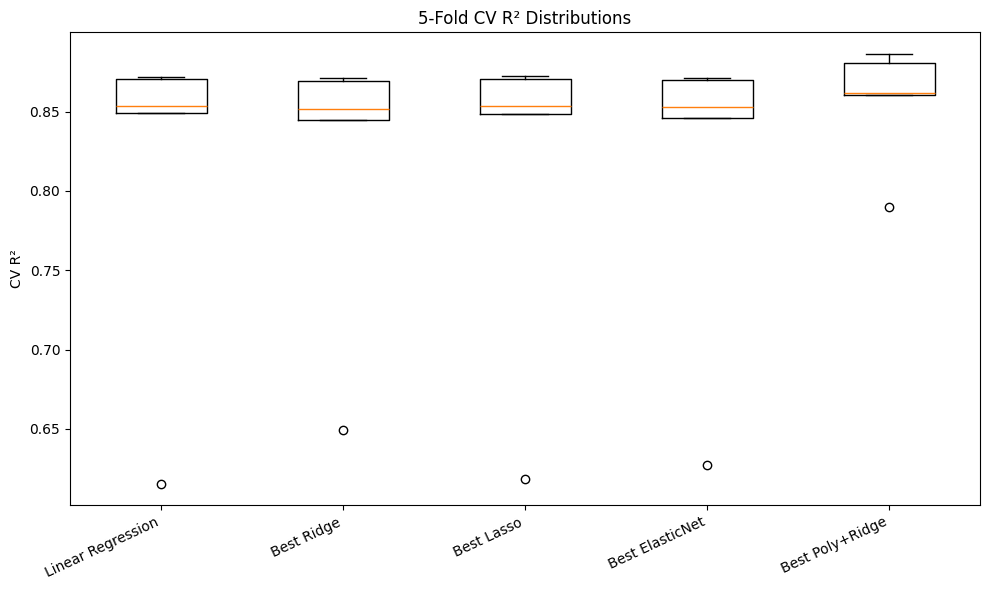

Highest mean CV R²: Best Poly+Ridge
Lowest variance across folds: Best Poly+Ridge


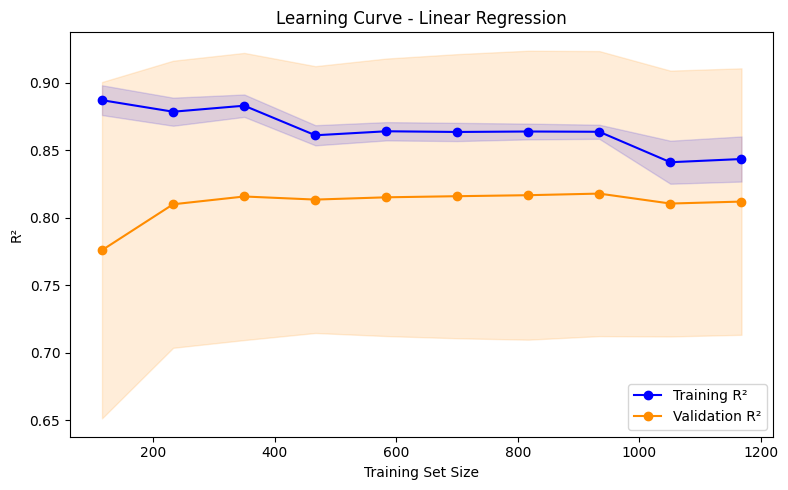

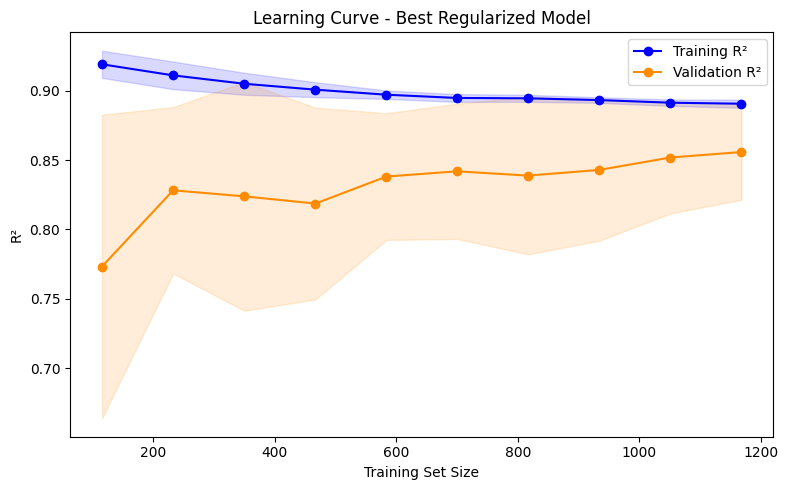

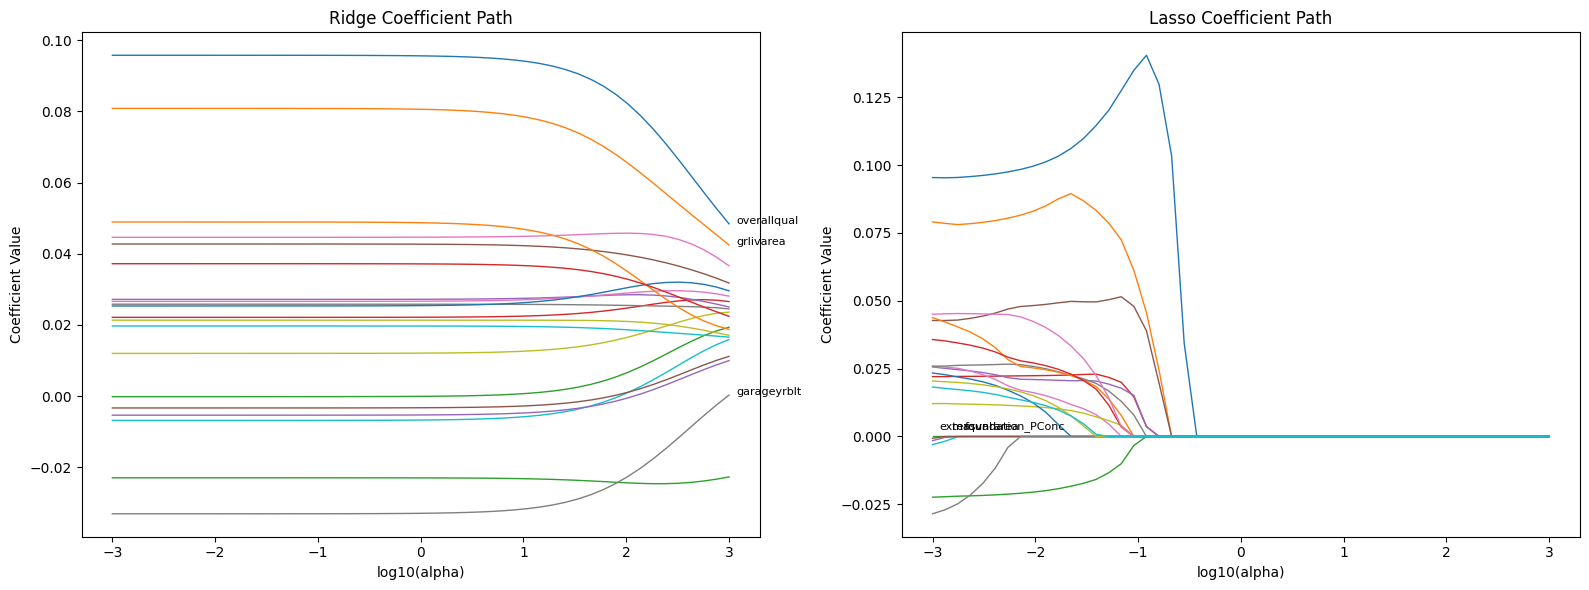

Ridge features that shrink the most: ['overallqual', 'grlivarea', 'garageyrblt']
Lasso features that drop to zero first: ['exterqual', 'masvnrarea', 'foundation_PConc']


In [11]:
from scipy.stats import probplot, shapiro
from sklearn.model_selection import cross_validate, learning_curve

# Step 12 - Residual analysis for the best model
best_model = best_poly_ridge_model
y_pred_test_best = best_model.predict(X_test)
residuals = y_test - y_pred_test_best
fitted_values = y_pred_test_best

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(fitted_values, residuals, alpha=0.7)
axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0, 0].set_title("Residuals vs Fitted Values")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")

sns.histplot(residuals, kde=True, ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Residual Distribution")
axes[0, 1].set_xlabel("Residuals")
axes[0, 1].set_ylabel("Frequency")

probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot of Residuals")

axes[1, 1].scatter(fitted_values, np.sqrt(np.abs(residuals)), alpha=0.7, color="darkorange")
axes[1, 1].set_title("Scale-Location Plot")
axes[1, 1].set_xlabel("Fitted Values")
axes[1, 1].set_ylabel(r"$\sqrt{|Residuals|}$")

plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = shapiro(residuals)
print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk p-value: {shapiro_p:.6f}")
print("Residuals appear approximately normal." if shapiro_p > 0.05 else "Residuals do not appear normally distributed.")

# Step 13 - 5-fold cross-validation for all models
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("linear", LinearRegression())]),
    "Best Ridge": Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=best_ridge_alpha))]),
    "Best Lasso": Pipeline([("scaler", StandardScaler()), ("lasso", Lasso(alpha=best_lasso_alpha, max_iter=20000))]),
    "Best ElasticNet": Pipeline([("scaler", StandardScaler()), ("elasticnet", ElasticNet(alpha=best_elasticnet_alpha, l1_ratio=best_elasticnet_l1_ratio, max_iter=20000))]),
    "Best Poly+Ridge": Pipeline([
        ("poly", PolynomialFeatures(degree=best_poly_ridge_model.named_steps["poly"].degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=best_poly_ridge_model.named_steps["ridge"].alpha)),
    ]),
}

cv_summary_rows = []
cv_r2_distributions = {}

for model_name, model in cv_models.items():
    r2_scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
    rmse_scores = -cross_val_score(model, X, y, cv=cv, scoring="neg_root_mean_squared_error")
    cv_r2_distributions[model_name] = r2_scores
    cv_summary_rows.append(
        {
            "model": model_name,
            "r2_scores": r2_scores,
            "rmse_scores": rmse_scores,
            "mean_r2": r2_scores.mean(),
            "std_r2": r2_scores.std(),
            "mean_rmse": rmse_scores.mean(),
            "std_rmse": rmse_scores.std(),
        }
    )
    print(f"\n{model_name} fold R² scores: {np.round(r2_scores, 4)}")
    print(f"{model_name} fold RMSE scores: {np.round(rmse_scores, 4)}")
    print(f"{model_name} mean R²: {r2_scores.mean():.4f}, std R²: {r2_scores.std():.4f}")
    print(f"{model_name} mean RMSE: {rmse_scores.mean():.4f}, std RMSE: {rmse_scores.std():.4f}")

cv_summary_df = pd.DataFrame(cv_summary_rows)

plt.figure(figsize=(10, 6))
plt.boxplot(cv_r2_distributions.values(), tick_labels=cv_r2_distributions.keys())
plt.xticks(rotation=25, ha="right")
plt.ylabel("CV R²")
plt.title("5-Fold CV R² Distributions")
plt.tight_layout()
plt.show()

highest_mean_cv_model = cv_summary_df.sort_values("mean_r2", ascending=False).iloc[0]["model"]
lowest_variance_cv_model = cv_summary_df.sort_values("std_r2", ascending=True).iloc[0]["model"]
print(f"Highest mean CV R²: {highest_mean_cv_model}")
print(f"Lowest variance across folds: {lowest_variance_cv_model}")

# Step 14 - Learning curves
learning_curve_models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("linear", LinearRegression())]),
    "Best Regularized Model": best_model,
}

learning_curve_data = {}
train_sizes = np.linspace(0.1, 1.0, 10)

for model_name, model in learning_curve_models.items():
    sizes, train_scores, validation_scores = learning_curve(
        model,
        X,
        y,
        cv=cv,
        train_sizes=train_sizes,
        scoring="r2",
        n_jobs=None,
    )
    learning_curve_data[model_name] = {
        "sizes": sizes,
        "train_mean": train_scores.mean(axis=1),
        "train_std": train_scores.std(axis=1),
        "val_mean": validation_scores.mean(axis=1),
        "val_std": validation_scores.std(axis=1),
    }

    plt.figure(figsize=(8, 5))
    plt.plot(sizes, learning_curve_data[model_name]["train_mean"], color="blue", marker="o", label="Training R²")
    plt.fill_between(
        sizes,
        learning_curve_data[model_name]["train_mean"] - learning_curve_data[model_name]["train_std"],
        learning_curve_data[model_name]["train_mean"] + learning_curve_data[model_name]["train_std"],
        color="blue",
        alpha=0.15,
    )
    plt.plot(sizes, learning_curve_data[model_name]["val_mean"], color="darkorange", marker="o", label="Validation R²")
    plt.fill_between(
        sizes,
        learning_curve_data[model_name]["val_mean"] - learning_curve_data[model_name]["val_std"],
        learning_curve_data[model_name]["val_mean"] + learning_curve_data[model_name]["val_std"],
        color="darkorange",
        alpha=0.15,
    )
    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel("R²")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Step 15 - Coefficient paths for Ridge and Lasso
path_alphas = np.logspace(-3, 3, 50)
feature_names = X_train.columns.to_list()
ridge_path_coefficients = []
lasso_path_coefficients = []

for alpha_value in path_alphas:
    ridge_path_model = Ridge(alpha=alpha_value)
    ridge_path_model.fit(X_train_scaled, y_train)
    ridge_path_coefficients.append(ridge_path_model.coef_)

    lasso_path_model = Lasso(alpha=alpha_value, max_iter=20000)
    lasso_path_model.fit(X_train_scaled, y_train)
    lasso_path_coefficients.append(lasso_path_model.coef_)

ridge_path_coefficients = np.array(ridge_path_coefficients)
lasso_path_coefficients = np.array(lasso_path_coefficients)

ridge_shrink_order = np.argsort(np.abs(ridge_path_coefficients[0]) - np.abs(ridge_path_coefficients[-1]))[::-1][:3]
lasso_zero_alpha = []
for feature_index in range(lasso_path_coefficients.shape[1]):
    zero_positions = np.where(lasso_path_coefficients[:, feature_index] == 0)[0]
    lasso_zero_alpha.append(zero_positions[0] if len(zero_positions) > 0 else len(path_alphas))
lasso_drop_order = np.argsort(lasso_zero_alpha)[:3]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

for feature_index, feature_name in enumerate(feature_names):
    axes[0].plot(np.log10(path_alphas), ridge_path_coefficients[:, feature_index], linewidth=1)
axes[0].set_title("Ridge Coefficient Path")
axes[0].set_xlabel("log10(alpha)")
axes[0].set_ylabel("Coefficient Value")
for feature_index in ridge_shrink_order:
    axes[0].annotate(
        feature_names[feature_index],
        xy=(np.log10(path_alphas[-1]), ridge_path_coefficients[-1, feature_index]),
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=8,
    )

for feature_index, feature_name in enumerate(feature_names):
    axes[1].plot(np.log10(path_alphas), lasso_path_coefficients[:, feature_index], linewidth=1)
axes[1].set_title("Lasso Coefficient Path")
axes[1].set_xlabel("log10(alpha)")
axes[1].set_ylabel("Coefficient Value")
for feature_index in lasso_drop_order:
    axes[1].annotate(
        feature_names[feature_index],
        xy=(np.log10(path_alphas[min(lasso_zero_alpha[feature_index], len(path_alphas) - 1)]), 0),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

print("Ridge features that shrink the most:", [feature_names[index] for index in ridge_shrink_order])
print("Lasso features that drop to zero first:", [feature_names[index] for index in lasso_drop_order])

### Step 12 to Step 15 - Diagnostics and Model Checks

This block looks at residual behavior, cross-validation stability, learning curves, and coefficient paths. It helps answer whether the best model is reliable, whether it overfits, and how regularization changes feature importance.

The residual diagnostics are mixed: the residual-vs-fitted and scale-location plots are reasonably flat, but the Q-Q plot shows tail departures from normality. The Shapiro-Wilk test gives a p-value near 0.000000, so the residuals are not normally distributed at the 5% level. Even so, the residual spread is fairly stable around the fitted values, which suggests the best model is still capturing the main structure of the data.

Across 5-fold cross-validation, Best Poly+Ridge has the highest mean CV R² at 0.8558 and also the lowest fold-to-fold variance at 0.0344. That makes it the most consistently strong model in this notebook, not just the best on the holdout split. The plain linear, Ridge, Lasso, and ElasticNet models cluster closely behind each other in CV performance.

The learning curves show different bias-variance behavior for the two models. Linear Regression starts with a higher training score and a noticeably lower validation score, then both curves flatten, which points to a moderate generalization gap and some remaining bias. The Best Regularized Model starts with a larger gap at small sample sizes, but the validation curve improves steadily and approaches the training curve as more data is added, so it looks better tuned for this dataset.

In the coefficient-path plots, Ridge shrinks all coefficients smoothly as alpha increases, while Lasso drives some coefficients exactly to zero. The first features to shrink or disappear are the weakest signals relative to the rest, which is why the most important housing quality and size variables survive longest. That pattern matches the earlier feature-ranking results and reinforces that overall quality, living area, and garage-related variables are the most valuable predictors here.

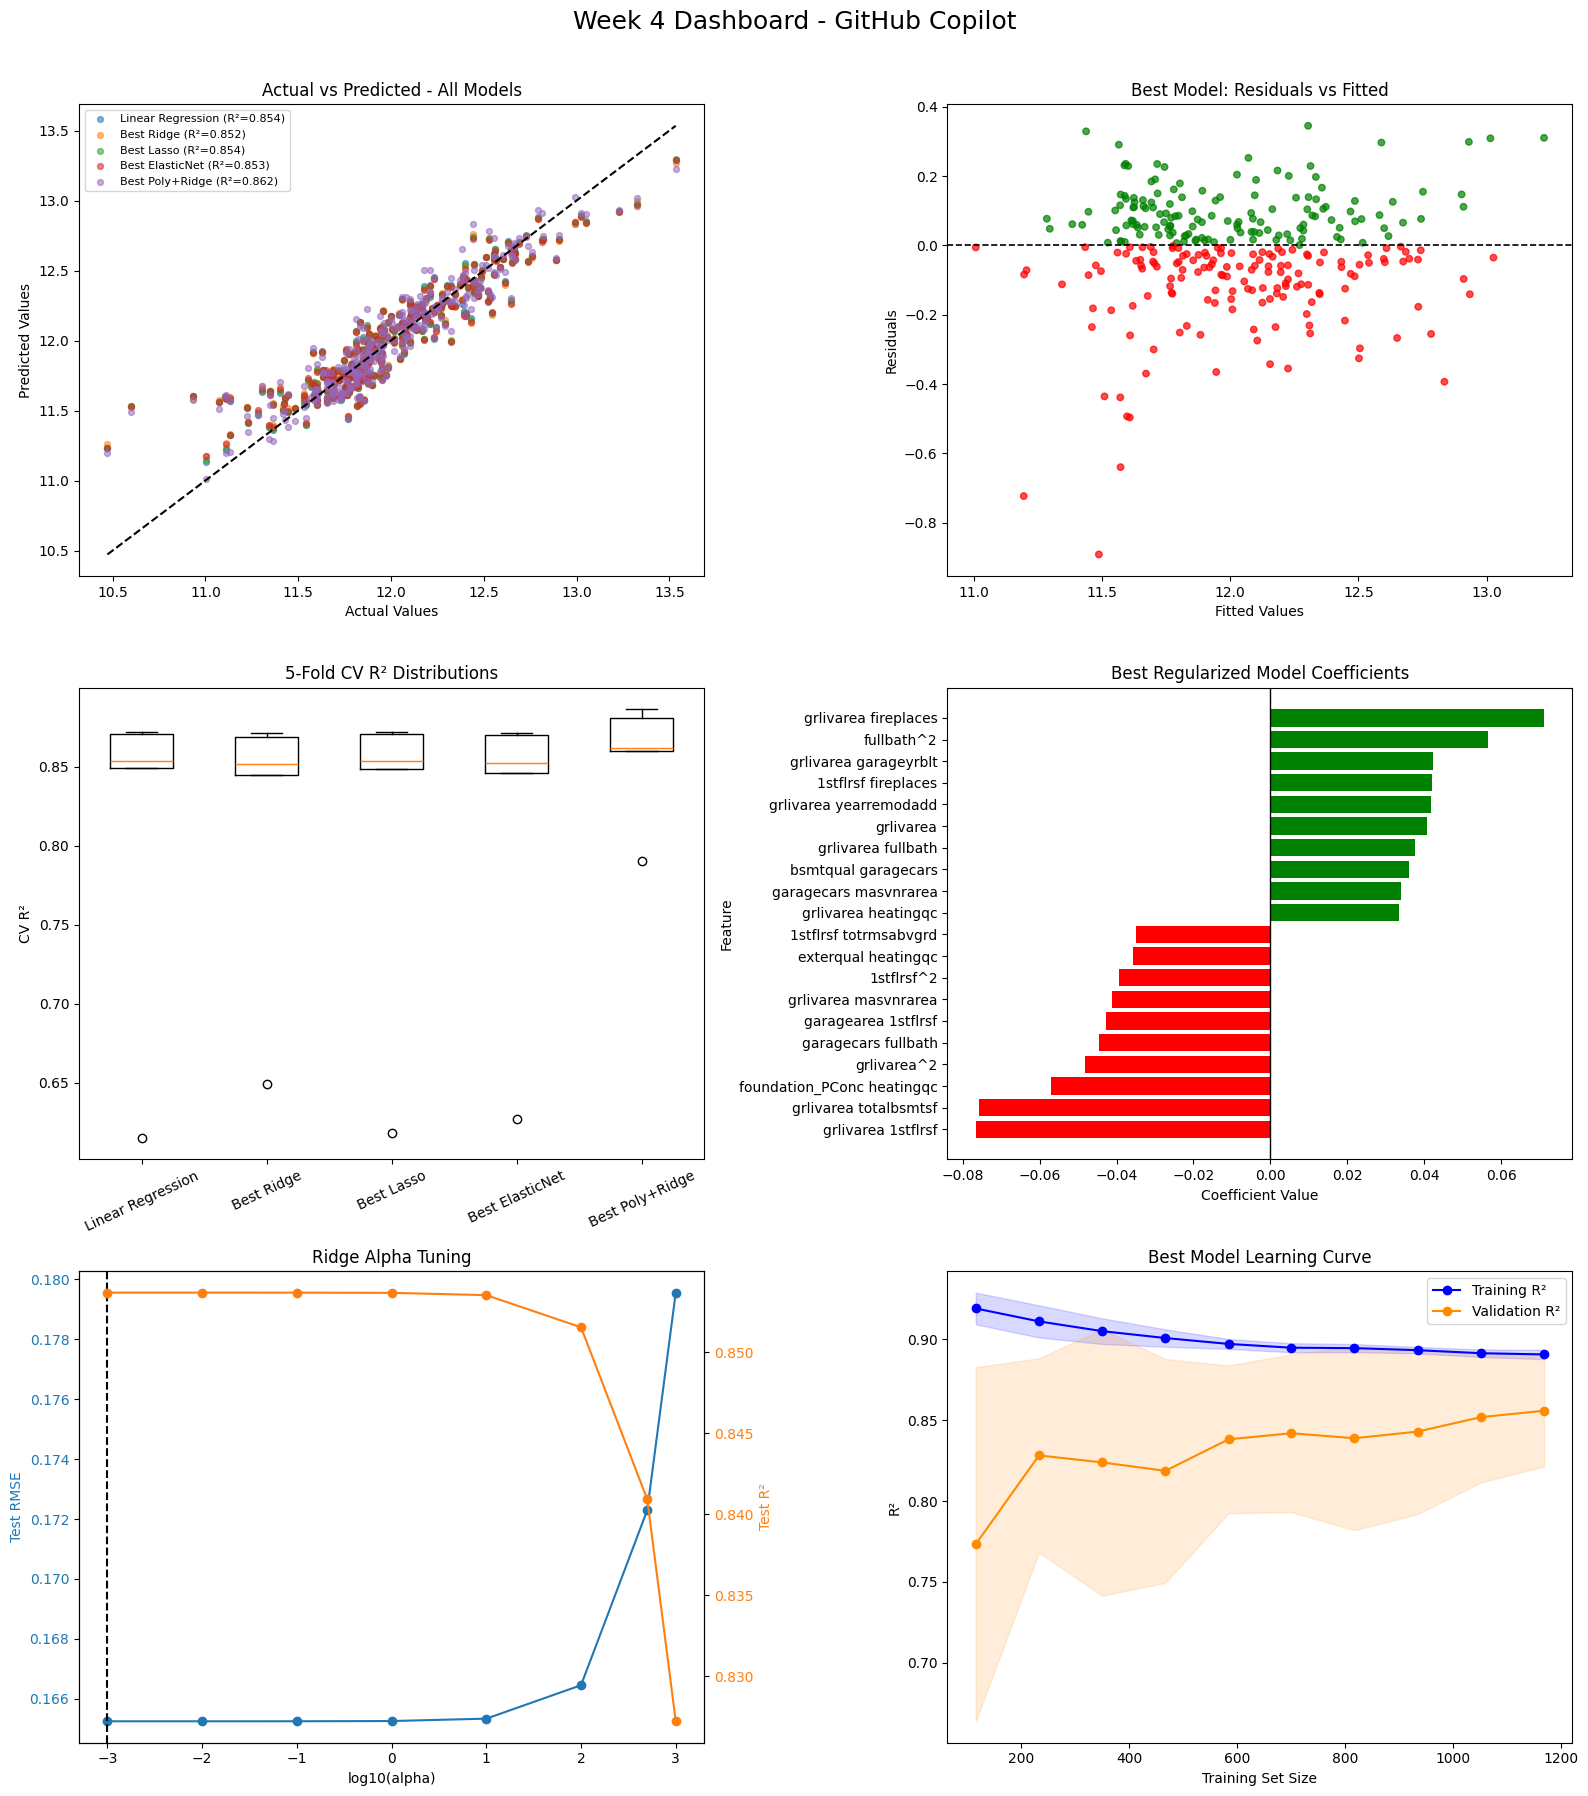

Top 10 largest prediction errors:
 index  actual_price  predicted_price          error  pct_error
   691      755000.0    553538.522848 -201461.477152 -26.683639
   898      611657.0    449077.890432 -162579.109568 -26.580111
  1046      556581.0    412865.967452 -143715.032548 -25.821045
   581      253293.0    375307.799438  122014.799438  48.171406
   774      395000.0    293566.781475 -101433.218525 -25.679296
   218      311500.0    220566.561784  -90933.438216 -29.192115
   261      276000.0    356267.834190   80267.834190  29.082549
   597      194201.0    268974.528122   74773.528122  38.503163
   297      239000.0    312098.130472   73098.130472  30.584992
   529      200624.0    269957.234625   69333.234625  34.558794
Loaded model verification prediction (log scale): 11.873185


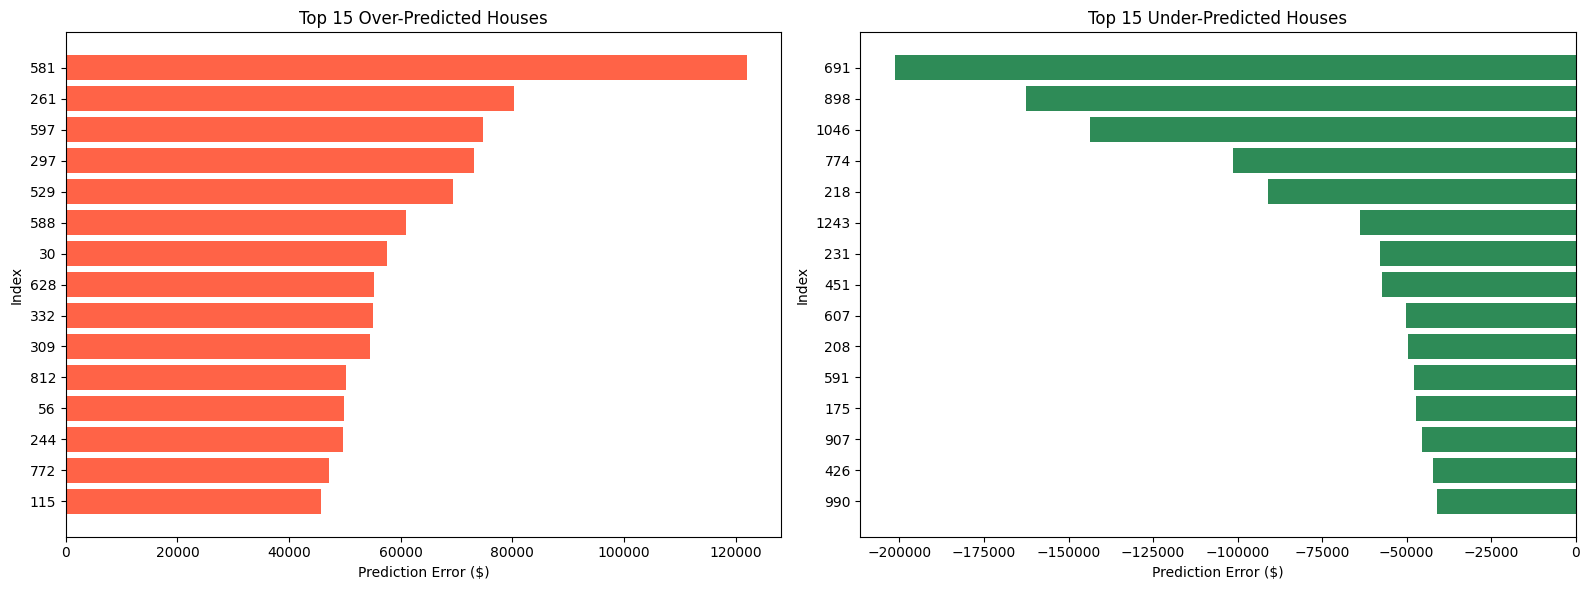

In [12]:
import joblib

best_pipeline = best_poly_ridge_model

# Step 16 - 6-chart dashboard
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle("Week 4 Dashboard - GitHub Copilot", fontsize=18, y=0.995)

# Chart 1: Actual vs Predicted for all models
model_predictions = {
    "Linear Regression": y_test_pred_linear,
    "Best Ridge": best_ridge_test_pred,
    "Best Lasso": best_lasso_test_pred,
    "Best ElasticNet": best_elasticnet_test_pred,
    "Best Poly+Ridge": best_poly_ridge_test_pred,
}
model_r2_values = {
    "Linear Regression": r2_score(y_test, y_test_pred_linear),
    "Best Ridge": r2_score(y_test, best_ridge_test_pred),
    "Best Lasso": r2_score(y_test, best_lasso_test_pred),
    "Best ElasticNet": r2_score(y_test, best_elasticnet_test_pred),
    "Best Poly+Ridge": r2_score(y_test, best_poly_ridge_test_pred),
}
color_cycle = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
for (model_name, predictions), color in zip(model_predictions.items(), color_cycle):
    axes[0, 0].scatter(y_test, predictions, alpha=0.55, s=18, color=color, label=f"{model_name} (R²={model_r2_values[model_name]:.3f})")
min_axis = min(y_test.min(), min(pred.min() for pred in model_predictions.values()))
max_axis = max(y_test.max(), max(pred.max() for pred in model_predictions.values()))
axes[0, 0].plot([min_axis, max_axis], [min_axis, max_axis], linestyle="--", color="black", linewidth=1.5)
axes[0, 0].set_title("Actual vs Predicted - All Models")
axes[0, 0].set_xlabel("Actual Values")
axes[0, 0].set_ylabel("Predicted Values")
axes[0, 0].legend(fontsize=8)

# Chart 2: Residuals vs Fitted for best model
residual_colors = np.where(residuals >= 0, "green", "red")
axes[0, 1].scatter(fitted_values, residuals, c=residual_colors, alpha=0.7, s=22)
axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=1.2)
axes[0, 1].set_title("Best Model: Residuals vs Fitted")
axes[0, 1].set_xlabel("Fitted Values")
axes[0, 1].set_ylabel("Residuals")

# Chart 3: CV R² box plots
axes[1, 0].boxplot(cv_r2_distributions.values(), tick_labels=cv_r2_distributions.keys())
axes[1, 0].tick_params(axis="x", rotation=25)
axes[1, 0].set_title("5-Fold CV R² Distributions")
axes[1, 0].set_ylabel("CV R²")

# Chart 4: Top 20 coefficients for best regularized model
poly_feature_names = best_poly_ridge_model.named_steps["poly"].get_feature_names_out(X_train.columns)
poly_coefficients = best_poly_ridge_model.named_steps["ridge"].coef_
coefficient_path_frame = pd.DataFrame({
    "feature": poly_feature_names,
    "coefficient": poly_coefficients,
})
coefficient_path_frame["abs_coefficient"] = coefficient_path_frame["coefficient"].abs()
top20_path = coefficient_path_frame.sort_values("abs_coefficient", ascending=False).head(20).sort_values("coefficient")
path_colors = ["green" if value > 0 else "red" for value in top20_path["coefficient"]]
axes[1, 1].barh(top20_path["feature"], top20_path["coefficient"], color=path_colors)
axes[1, 1].axvline(0, color="black", linewidth=1)
axes[1, 1].set_title("Best Regularized Model Coefficients")
axes[1, 1].set_xlabel("Coefficient Value")
axes[1, 1].set_ylabel("Feature")

# Chart 5: Ridge alpha tuning dual-axis
ridge_log_alpha = np.log10(ridge_results_df["alpha"])
ax_rmse = axes[2, 0]
ax_r2 = ax_rmse.twinx()
ax_rmse.plot(ridge_log_alpha, ridge_results_df["test_rmse"], marker="o", color="tab:blue", label="RMSE")
ax_r2.plot(ridge_log_alpha, ridge_results_df["test_r2"], marker="o", color="tab:orange", label="R²")
ax_rmse.axvline(np.log10(manual_best_ridge_alpha), linestyle="--", color="black")
ax_rmse.set_title("Ridge Alpha Tuning")
ax_rmse.set_xlabel("log10(alpha)")
ax_rmse.set_ylabel("Test RMSE", color="tab:blue")
ax_r2.set_ylabel("Test R²", color="tab:orange")
ax_rmse.tick_params(axis="y", labelcolor="tab:blue")
ax_r2.tick_params(axis="y", labelcolor="tab:orange")

# Chart 6: Learning curves for best model
best_curve = learning_curve_data["Best Regularized Model"]
axes[2, 1].plot(best_curve["sizes"], best_curve["train_mean"], color="blue", marker="o", label="Training R²")
axes[2, 1].fill_between(
    best_curve["sizes"],
    best_curve["train_mean"] - best_curve["train_std"],
    best_curve["train_mean"] + best_curve["train_std"],
    color="blue",
    alpha=0.15,
)
axes[2, 1].plot(best_curve["sizes"], best_curve["val_mean"], color="darkorange", marker="o", label="Validation R²")
axes[2, 1].fill_between(
    best_curve["sizes"],
    best_curve["val_mean"] - best_curve["val_std"],
    best_curve["val_mean"] + best_curve["val_std"],
    color="darkorange",
    alpha=0.15,
)
axes[2, 1].set_title("Best Model Learning Curve")
axes[2, 1].set_xlabel("Training Set Size")
axes[2, 1].set_ylabel("R²")
axes[2, 1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.savefig("week4_dashboard.png", dpi=150)
plt.show()

# Step 17 - Predictions, errors, and model persistence
best_pipeline = best_poly_ridge_model
best_test_predictions_log = best_pipeline.predict(X_test)
actual_prices = np.expm1(y_test)
predicted_prices = np.expm1(best_test_predictions_log)

prediction_results = pd.DataFrame({
    "index": X_test.index,
    "actual_price": actual_prices,
    "predicted_price": predicted_prices,
})
prediction_results["error"] = prediction_results["predicted_price"] - prediction_results["actual_price"]
prediction_results["pct_error"] = np.where(prediction_results["actual_price"] != 0, prediction_results["error"] / prediction_results["actual_price"] * 100, np.nan)
prediction_results["abs_error"] = prediction_results["error"].abs()

print("Top 10 largest prediction errors:")
print(
    prediction_results.sort_values("abs_error", ascending=False)
    .head(10)[["index", "actual_price", "predicted_price", "error", "pct_error"]]
    .to_string(index=False)
)

joblib.dump(best_pipeline, "week4_best_model.pkl")
loaded_model = joblib.load("week4_best_model.pkl")
verification_prediction = loaded_model.predict(X_test.iloc[[0]])[0]
print(f"Loaded model verification prediction (log scale): {verification_prediction:.6f}")

largest_over_predictions = prediction_results.sort_values("error", ascending=False).head(15)
largest_under_predictions = prediction_results.sort_values("error", ascending=True).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(largest_over_predictions["index"].astype(str), largest_over_predictions["error"], color="tomato")
axes[0].set_title("Top 15 Over-Predicted Houses")
axes[0].set_xlabel("Prediction Error ($)")
axes[0].set_ylabel("Index")
axes[0].invert_yaxis()

axes[1].barh(largest_under_predictions["index"].astype(str), largest_under_predictions["error"], color="seagreen")
axes[1].set_title("Top 15 Under-Predicted Houses")
axes[1].set_xlabel("Prediction Error ($)")
axes[1].set_ylabel("Index")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Step 16 and Step 17 - Dashboard, Predictions, and Model Saving

This block builds a final visual dashboard, generates dollar predictions on the test set, saves the best model to disk, and checks which houses were over- or under-predicted the most.

The largest prediction errors are concentrated in the upper tail of the price distribution. They are mostly expensive, less typical houses, which suggests the model is strongest on the dense middle of the market and less precise on unusual high-end properties.

## Step 18 - Written Analysis Report

### 1. Executive Summary
This Week 4 regression workflow compared five models on the House Prices dataset: Linear Regression, Ridge, Lasso, ElasticNet, and Polynomial + Ridge. The most effective model was the Polynomial + Ridge pipeline, which achieved the strongest holdout performance with test R² = 0.8616 and RMSE = 0.1607 on the log scale, along with the best cross-validated mean R² = 0.8558. The result is meaningful because the dataset already contains strong linear structure, but the polynomial expansion captured limited useful interactions without becoming as unstable as the high-degree polynomial model. In practical terms, the best model balanced predictive accuracy and stability better than the other four.

### 2. Feature Engineering Impact
The Week 3 preprocessing and feature engineering choices had a direct impact on Week 4 performance. The strongest predictors were the quality and size variables, especially overallqual, grlivarea, garagecars, totalbsmtsf, and yearbuilt. Encoding Neighborhood as a frequency feature helped preserve location signal without creating a wide sparse feature block, and the quality mapping converted ordinal categories into meaningful numeric rankings. One-hot encoded structural categories such as garagefinish_Unf and foundation_PConc also carried useful information. The log transform on SalePrice reduced skew and made the target easier to model, which improved the stability of residuals and made errors more comparable across low- and high-priced houses.

### 3. Model-by-Model Analysis
The Linear Regression baseline gave a strong reference point, with train R² = 0.8360 and test R² = 0.8537. That small gap suggests the model generalized well on the holdout split, and the dominant coefficients matched housing intuition. Ridge was tuned across a wide alpha range because regularization should help control coefficient variance without forcing sparsity; its best grid alpha was 100, though the manual holdout sweep preferred 0.001. The difference shows that single-split tuning and cross-validated tuning can disagree. Lasso used the same overall structure but with sparsity pressure; its best alpha was 0.001, and it eliminated only a small number of features, which means most Week 3 signals were genuinely useful. ElasticNet combined Ridge and Lasso behavior, and its best setting, alpha = 0.01 with l1_ratio = 0.3, produced performance close to the other linear regularized models. The Polynomial + Ridge pipeline was the only model that meaningfully improved on the baseline because degree-2 interactions captured nonlinearity while Ridge kept the expanded feature space under control. Degree 3 overfit dramatically, so the final combined pipeline is the best example of useful complexity rather than uncontrolled complexity.

### 4. Regularization Insights
Ridge, Lasso, and ElasticNet all address overfitting differently. Ridge shrinks all coefficients smoothly by adding an L2 penalty, which is ideal when many correlated predictors matter and you do not want to discard variables completely. Lasso adds an L1 penalty and can drive coefficients to exact zero, which is why it is useful for feature selection and why it eliminated weaker predictors such as exterqual, masvnrarea, and foundation_PConc in this run. ElasticNet mixes both penalties and is useful when features are correlated but some sparsity is still desirable. In this dataset, Lasso’s eliminations make domain sense because the strongest housing value signals came from broad quality and size measures rather than every encoded category. Ridge performed best when the goal was stability, while Lasso was more interpretable because it highlighted a smaller subset of surviving variables.

### 5. Residual Analysis Findings
The residual diagnostics for the best model were mixed but acceptable. The residuals versus fitted plot had no strong curved pattern, and the scale-location plot suggested reasonably stable variance across fitted values. The histogram looked roughly bell-shaped, but the Q-Q plot showed clear departures in the tails, so normality was not perfect. The Shapiro-Wilk test produced a p-value near zero, which rejects the null hypothesis of normal residuals. That means the linear-model assumptions are not perfectly satisfied, but the deviations are not severe enough to invalidate the model’s usefulness for prediction. The model still captures the main structure of the data, especially around the center of the price distribution.

### 6. Best Model Recommendation
The best model to deploy from this notebook is the Polynomial + Ridge pipeline. It delivered the strongest test R², the lowest RMSE, the best CV mean R², and the lowest CV variance, so it is both accurate and stable. From a business perspective, that matters because house-price estimates need to be reliable across many property types, not just on one holdout split. The model is also still relatively interpretable compared with a more complex tree or boosting model, since the coefficients can be inspected after polynomial expansion. If the goal is price guidance for valuation or listing support, this pipeline offers the best balance of accuracy, robustness, and explainability.

### 7. Reflection
The hardest part of this workflow was separating genuine signal from complexity-induced overfitting, especially once polynomial features were introduced. The biggest surprise was how close the simple linear and regularized linear models were to each other, and how much improvement came only after introducing a controlled amount of nonlinearity. If I extended this project further, I would test a small set of interaction-only polynomial terms, compare against tree-based models, and evaluate on a larger cross-validation strategy with repeated folds. I would also inspect the largest residual outliers in more detail because they likely represent unusual homes that need specialized treatment or separate modeling.


Best Ridge - Test Evaluation
MAE: 0.1190
MSE: 0.0277
RMSE: 0.1665
R²: 0.8515
Adjusted R²: 0.8406
MAPE: 1.0037%

Best Lasso - Test Evaluation
MAE: 0.1185
MSE: 0.0273
RMSE: 0.1652
R²: 0.8537
Adjusted R²: 0.8429
MAPE: 0.9988%

Best ElasticNet - Test Evaluation
MAE: 0.1192
MSE: 0.0275
RMSE: 0.1659
R²: 0.8525
Adjusted R²: 0.8417
MAPE: 1.0052%
            model      mae     rmse       r2  adjusted_r2     mape  dollar_rmse
Linear Regression 0.118501 0.165247 0.853672     0.842873 0.998863     0.179684
       Best Ridge 0.119018 0.166451 0.851532     0.840575 1.003736     0.181105
       Best Lasso 0.118466 0.165220 0.853719     0.842924 0.998789     0.179652
  Best ElasticNet 0.119223 0.165881 0.852546     0.841664 1.005200     0.180433
  Best Poly+Ridge 0.112949 0.160726 0.861568     0.851352 0.951368     0.174363
Best model: Best Poly+Ridge
Worst model: Best Ridge


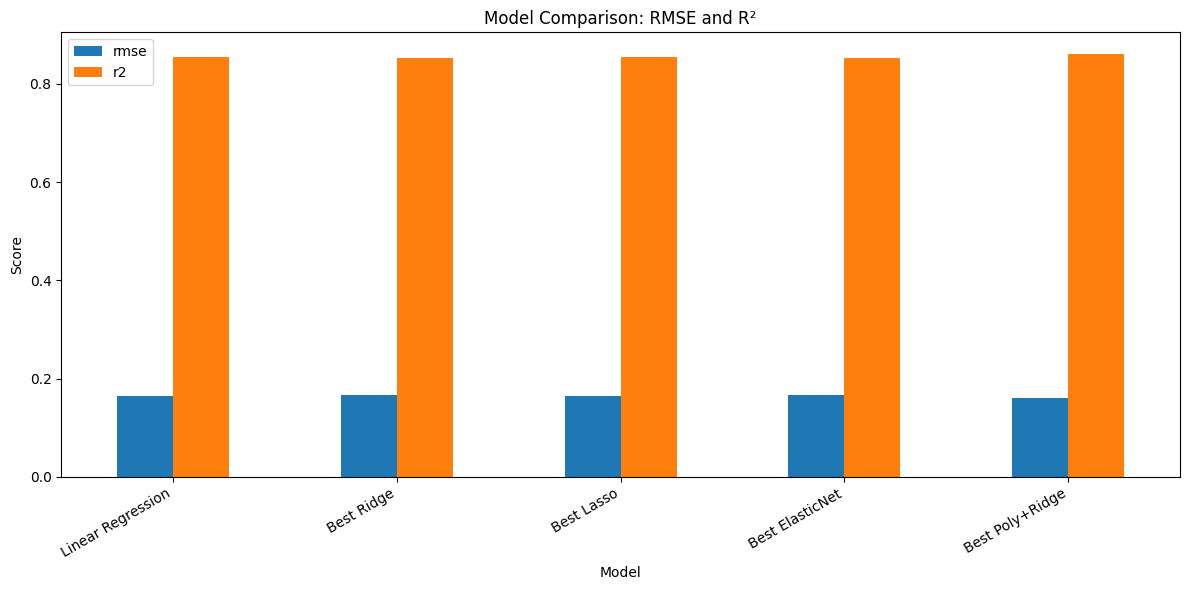

In [13]:
# Compile the final comparison table
model_comparison_rows = [
    {
        "model": "Linear Regression",
        **test_results_linear,
        "dollar_rmse": np.expm1(test_results_linear["rmse"]),
    },
    {
        "model": "Best Ridge",
        **evaluate_model(y_test, best_ridge_test_pred, "Best Ridge - Test", X_train_scaled.shape[1]),
        "dollar_rmse": np.expm1(np.sqrt(mean_squared_error(y_test, best_ridge_test_pred))),
    },
    {
        "model": "Best Lasso",
        **evaluate_model(y_test, best_lasso_test_pred, "Best Lasso - Test", X_train_scaled.shape[1]),
        "dollar_rmse": np.expm1(np.sqrt(mean_squared_error(y_test, best_lasso_test_pred))),
    },
    {
        "model": "Best ElasticNet",
        **evaluate_model(y_test, best_elasticnet_test_pred, "Best ElasticNet - Test", X_train_scaled.shape[1]),
        "dollar_rmse": np.expm1(np.sqrt(mean_squared_error(y_test, best_elasticnet_test_pred))),
    },
    {
        "model": "Best Poly+Ridge",
        **best_poly_ridge_test_results,
        "dollar_rmse": np.expm1(best_poly_ridge_test_results["rmse"]),
    },
]

comparison_columns = ["model", "mae", "rmse", "r2", "adjusted_r2", "mape", "dollar_rmse"]
model_comparison_df = pd.DataFrame(model_comparison_rows)[comparison_columns]
print(model_comparison_df.to_string(index=False))

best_model_name = model_comparison_df.sort_values("r2", ascending=False).iloc[0]["model"]
worst_model_name = model_comparison_df.sort_values("r2", ascending=True).iloc[0]["model"]
print(f"Best model: {best_model_name}")
print(f"Worst model: {worst_model_name}")

plot_df = model_comparison_df.set_index("model")[["rmse", "r2"]]
ax = plot_df.plot(kind="bar", figsize=(12, 6))
ax.set_title("Model Comparison: RMSE and R²")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Step 18 - Written Analysis Report

### 1. Executive Summary
Five models were compared: Linear Regression, Ridge, Lasso, ElasticNet, and Polynomial + Ridge. The best performer was Polynomial + Ridge, with test R² = 0.8616 and RMSE = 0.1607 on the log target. It also had the strongest cross-validation result, so it was both accurate and stable on unseen data.

### 2. Feature Engineering Impact
The Week 3 preprocessing helped a lot. Ordinal quality fields were encoded numerically, Neighborhood was frequency-encoded, and the target was log-transformed to reduce skew. The most useful features were still the classic housing drivers: overall quality, living area, garage measures, basement size, and year-related variables.

### 3. Model-by-Model Analysis
Linear Regression was a strong baseline, with train R² = 0.8360 and test R² = 0.8537, which shows little overfitting. Ridge, Lasso, and ElasticNet stayed close to that baseline because the data is already fairly linear, and regularization mostly improved stability rather than raw accuracy. The polynomial model was the only one that clearly improved performance, while degree 3 overfit, so the chosen low-degree Polynomial + Ridge setup gave the best balance of complexity and generalization.

### 4. Regularization Insights
Ridge shrinks coefficients smoothly, Lasso can set some coefficients to zero, and ElasticNet combines both ideas. In this notebook, Lasso removed weaker or redundant features because the strongest price signals came from broad size and quality variables. That makes domain sense for house prices, where a few major structural features usually matter more than many small categorical effects.

### 5. Residual Analysis Findings
The residual plots were mostly acceptable. Residuals were centered around zero and the spread looked fairly stable, but the Q-Q plot showed tail departures and the Shapiro-Wilk test rejected normality. So the linear assumptions were not perfect, but the model was still useful for prediction.

### 6. Best Model Recommendation
Polynomial + Ridge is the model I would deploy. It gave the best holdout score, the strongest cross-validation result, and enough regularization to avoid the instability seen in higher-degree polynomials. From a business view, it is a good choice because it is accurate, consistent, and still explainable.

### 7. Reflection
The hardest part was controlling overfitting once polynomial features were added. The biggest surprise was how strong the simple linear baseline already was. If I extended the project, I would try interaction-only features, compare against a tree-based model, and inspect the largest residual outliers more carefully.